<a href="https://colab.research.google.com/github/JordanBaker78/Data205_JordanBaker/blob/main/CapstoneProject_Ingestion_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install nflreadpy

In [4]:
import pandas as pd
import nflreadpy  as nfl
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [44]:
stats_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2023.csv')
stats_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2022.csv')
stats_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2021.csv')
stats_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2020.csv')
stats_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2019.csv')

In [45]:
stats = pd.concat((stats_2023, stats_2022, stats_2021, stats_2020, stats_2019))
stats.tail()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_tds,pass_cmp,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
529,2019,2020-01-19,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,27,112,2,23,...,61,27,6,10,0.600,1,1,1.000,1790,https://www.pro-football-reference.com/boxscor...
530,2019,2020-01-19,D5QY6bOxfn8ZL,Green Bay,Packers,GB,16,62,1,31,...,46,21,3,9,0.333,2,2,1.000,1873,https://www.pro-football-reference.com/boxscor...
531,2019,2020-01-19,IwSI92ZDKoazn,San Francisco,49ers,SF,42,285,4,6,...,10,19,4,10,0.400,0,0,0.000,1727,https://www.pro-football-reference.com/boxscor...
532,2019,2020-02-02,IwSI92ZDKoazn,San Francisco,49ers,SF,22,141,1,20,...,45,21,3,8,0.375,0,1,0.000,1607,https://www.pro-football-reference.com/boxscor...
533,2019,2020-02-02,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,29,129,2,26,...,24,26,6,14,0.429,2,3,0.667,1993,https://www.pro-football-reference.com/boxscor...


In [46]:
#Add Column named "rush_avg"
rush_avg = stats['rush_yds'] / stats['rush_att']
stats.insert(8, 'rush_avg', rush_avg)
stats.head()


,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,0,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,1,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,3,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,3,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,1,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [47]:
#add Column named "pass_avg"
pass_avg = stats['pass_yds'] / stats['pass_cmp']
stats.insert(15, 'pass_avg', pass_avg)
stats.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,0,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,1,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,3,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,3,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,1,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [49]:
stats_2019 = stats[stats['season'] == 2019]
stats_2020 = stats[stats['season'] == 2020]
stats_2021 = stats[stats['season'] == 2021]
stats_2022 = stats[stats['season'] == 2022]
stats_2023 = stats[stats['season'] == 2023]
stats_2019.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2019,2019-09-05,D5QY6bOxfn8ZL,Green Bay,Packers,GB,22,47,2.136364,0,...,71,13,2,12,0.167,0,0,0.0,1863,https://www.pro-football-reference.com/boxscor...
1,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,15,46,3.066667,0,...,107,16,3,15,0.200,0,2,0.0,1737,https://www.pro-football-reference.com/boxscor...
2,2019,2019-09-08,mLspw4gJNTQGN,Atlanta,Falcons,ATL,17,73,4.294118,0,...,78,27,2,8,0.250,2,2,1.0,1813,https://www.pro-football-reference.com/boxscor...
3,2019,2019-09-08,AzOs5UWsXusSW,Minnesota,Vikings,MIN,38,172,4.526316,3,...,100,18,5,10,0.500,0,0,0.0,1787,https://www.pro-football-reference.com/boxscor...
4,2019,2019-09-08,3VqeLK0LS9rpw,Buffalo,Bills,BUF,25,128,5.120000,1,...,55,23,5,10,0.500,0,1,0.0,1679,https://www.pro-football-reference.com/boxscor...


In [58]:
#Create dataframes for Rushing Stats for each year
rushing_2019 = stats_2019[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2020 = stats_2020[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2021 = stats_2021[['name', 'rush_att', 'rush_yds', 'rush_avg','rush_tds']]
rushing_2022 = stats_2022[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2023 = stats_2023[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_total = stats[['season', 'name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_total.head()

,season,name,rush_att,rush_yds,rush_avg,rush_tds
0,2023,Ravens,16,81,5.062500,0
1,2023,Chiefs,32,89,2.781250,1
2,2023,49ers,33,155,4.696970,3
3,2023,Lions,29,182,6.275862,3
4,2023,Chiefs,24,146,6.083333,1


In [57]:
#Create dataframes for Passing stats for each year
passing_2019 = stats_2019[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2020 = stats_2020[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2021 = stats_2021[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2022 = stats_2022[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2023 = stats_2023[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_total = stats[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2019.head()

,name,pass_att,pass_cmp,pass_avg,pass_tds,pass_int,passer_rating,net_pass_yds,times_sacked,yds_sacked_for
0,Packers,30,18,11.277778,1,0,91.389,166,5,37
1,Bears,45,26,8.769231,0,1,62.083,208,5,20
2,Falcons,46,33,9.212121,2,2,85.779,272,4,32
3,Vikings,10,8,12.250000,1,0,140.833,97,1,1
4,Bills,37,24,10.583333,1,2,71.227,242,1,12


<Axes: xlabel='name', ylabel='rush_att'>

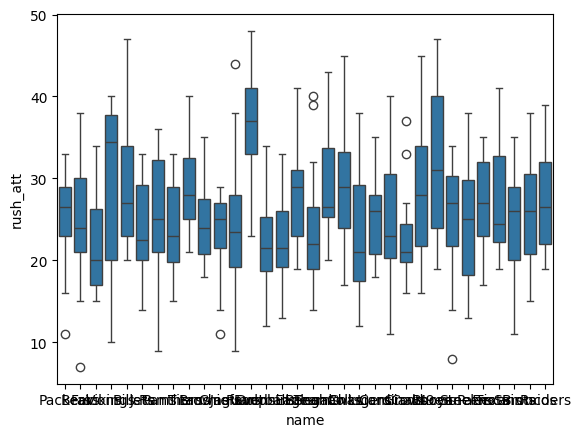

In [ ]:
#Plot that shows the distribution of rushing atts by team
sns.boxplot(data=rushing_2019, x="name", y="rush_att")

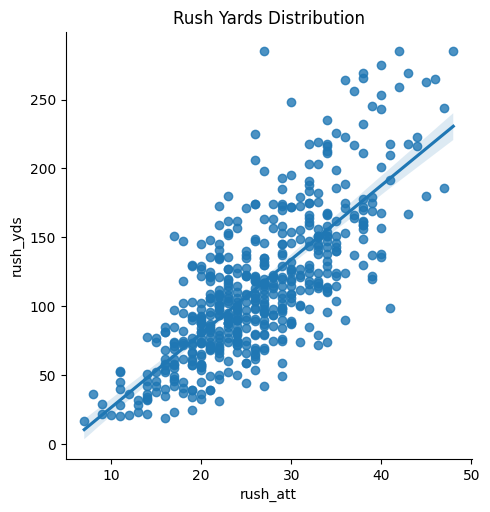

In [ ]:
#Plot shows rush atts vs rush yards 2019
sns.lmplot(data=rushing_2019, x="rush_att", y="rush_yds")
plt.title("Rush Yards Distribution")
plt.show()

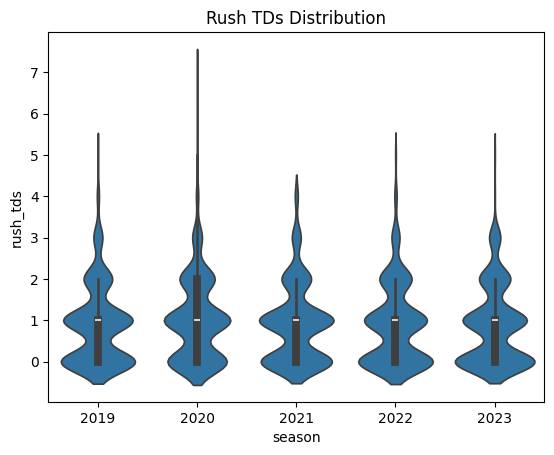

In [ ]:
#violin plot (x = 'season', y = rushing (atts, yds, tds) vs. passing (atts, yds, tds))

sns.violinplot(data=stats, x="season", y="rush_tds")
plt.title("Rush TDs Distribution")
plt.show()

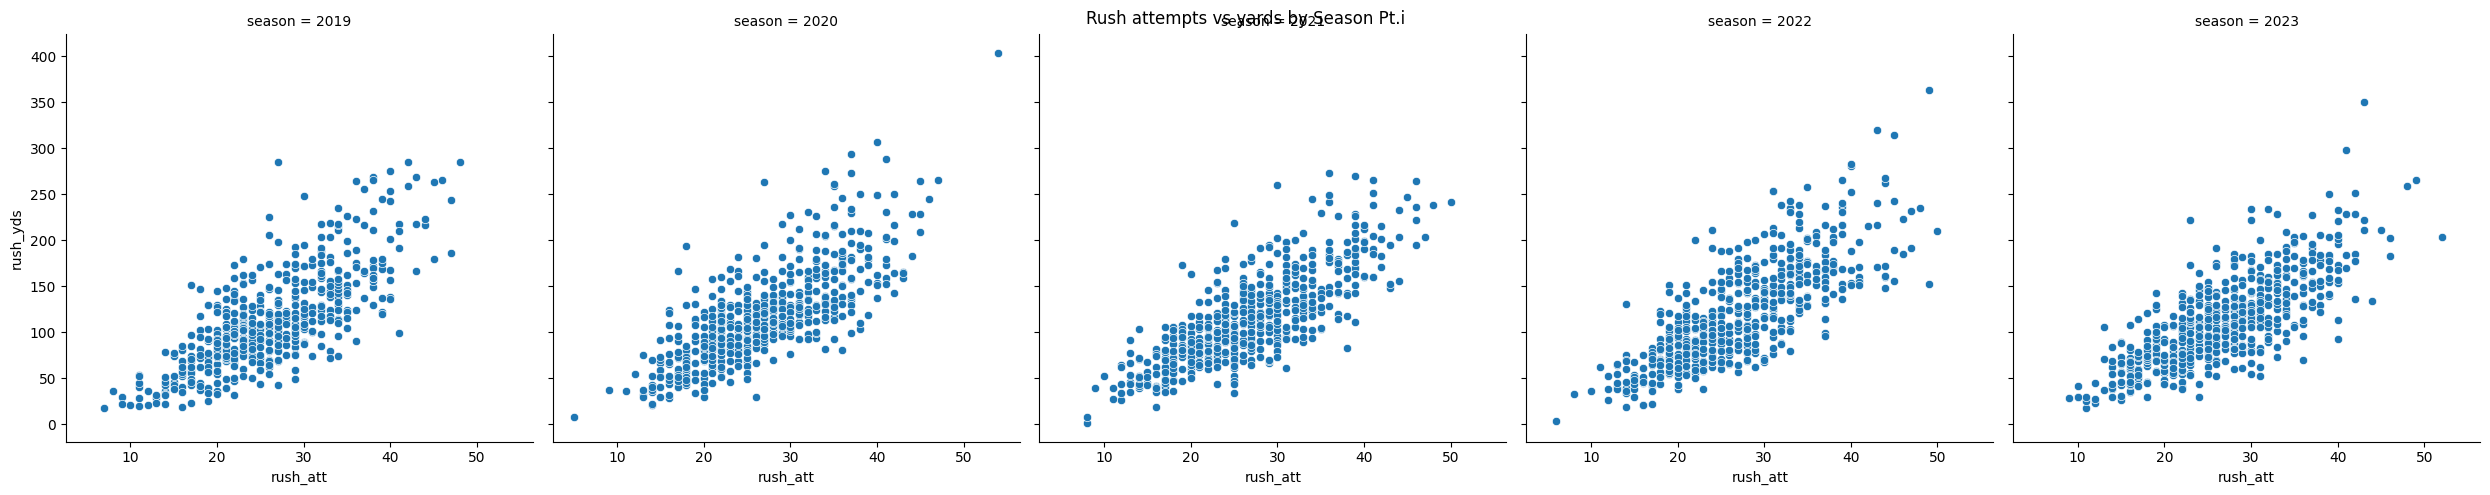

In [62]:
#Plot to show rushing distribution (attemps vs yards) sperated by season
sns.relplot(data=rushing_total, x="rush_att", y="rush_yds", col="season")
plt.suptitle("Rush attempts vs yards by Season Pt.i")
plt.show()
##I think this might be the coolest visulization so far.

This shows that there is not a big differnce in the running game from season to season. The distribution is extremly similar across each season.

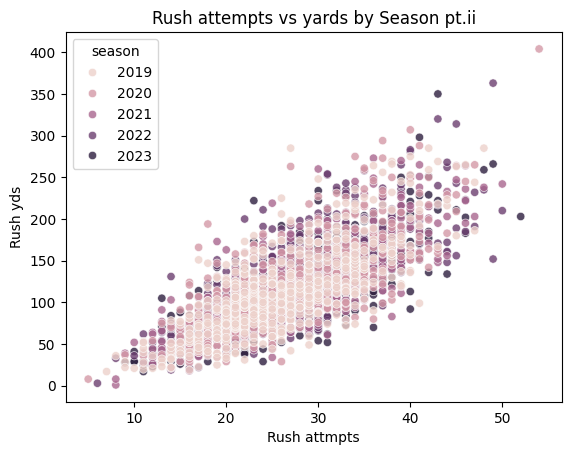

In [65]:
sns.scatterplot(data=stats, x="rush_att", y="rush_yds", hue = "season", alpha = 0.8)
plt.title("Rush attempts vs yards by Season pt.ii")
plt.xlabel("Rush attmpts")
plt.ylabel("Rush yds")
plt.show()

<Axes: xlabel='name', ylabel='passer_rating'>

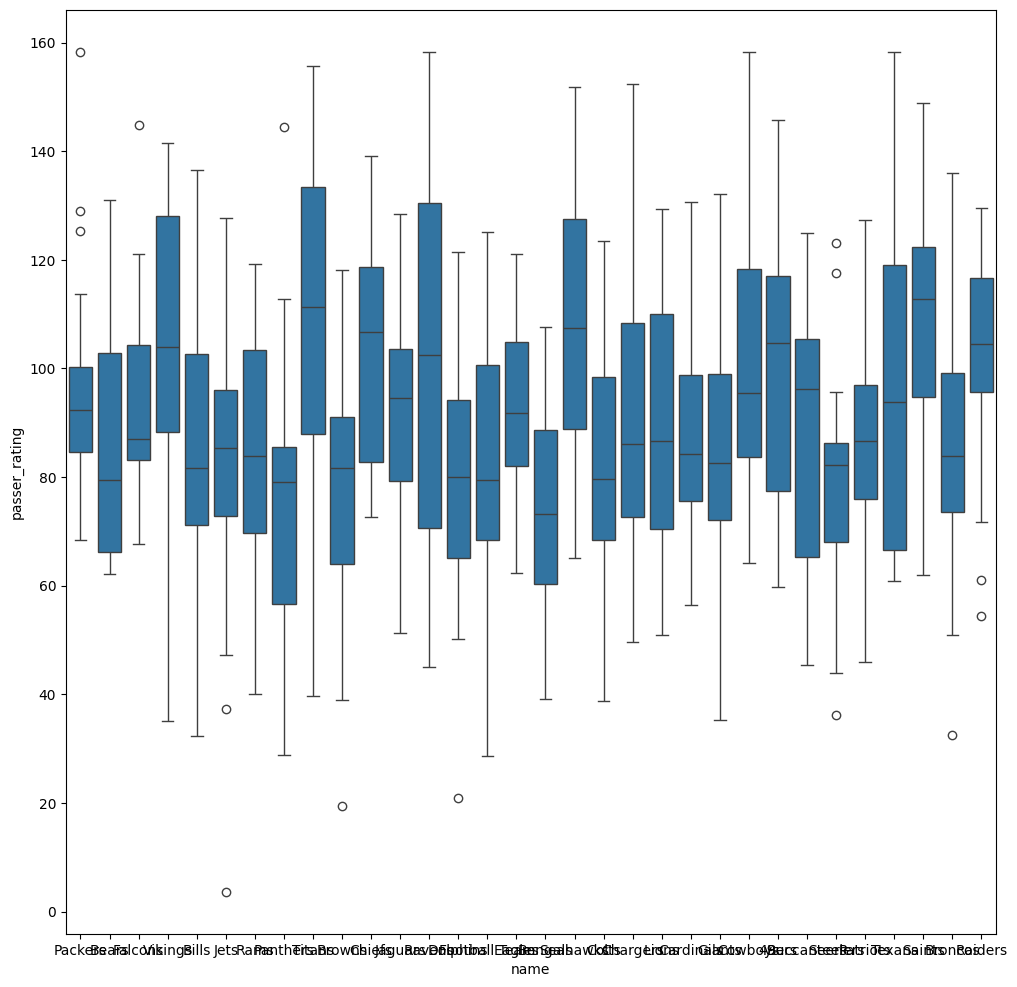

In [ ]:
#distribution plot for passer rating by team

plt.figure(figsize=(12, 12))
sns.boxplot(data=Passing_2019, x="name", y="passer_rating")

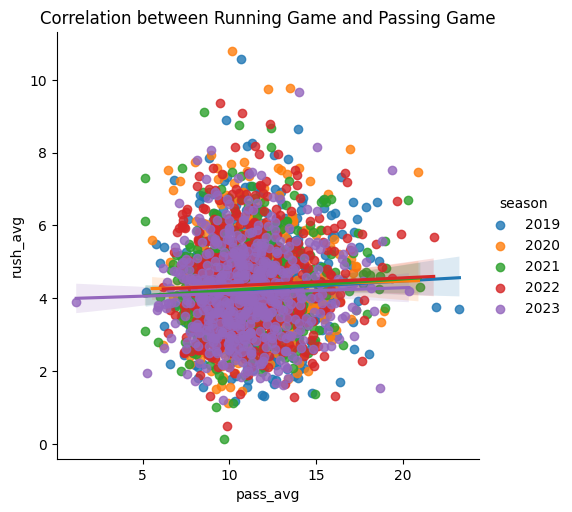

In [61]:
#Correlation between running game and passing game (linear regression)
sns.lmplot(data=stats, x='pass_avg', y='rush_avg', hue='season')
plt.title("Correlation between Running Game and Passing Game")
plt.show()